#  Обратное распространение ошибки

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* http://cs231n.stanford.edu/handouts/linear-backprop.pdf
* https://www.adityaagrawal.net/blog/deep_learning/bprop_fc
* https://en.wikipedia.org/wiki/Stochastic_gradient_descent

In [ ]:
!pip install torchtyping

  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.4.4
    Uninstalling typeguard-4.4.4:
      Successfully uninstalled typeguard-4.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked
import torch as th

Scalar = TensorType[()]
patch_typeguard()

## Задачи для совместного разбора

1\. Реализуйте обратное распространение ошибки для модели нейрона с квадратичной функцией потерь при условии, что на вход нейрону поступает вектор `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

In [ ]:
class Neuron:
    def __init__(self, n_features):
        # <создать атрибуты объекта weights и bias>
        self.weights = th.randn(n_features, 1, requires_grad = False)
        self.bias = th.randn(1, requires_grad = False)
        print(f"Смещение:{self.bias.item()}, Веса:{self.weights.tolist()}")
    def forward(self, inputs: TensorType["n_features"]) -> Scalar:
        return th.matmul(inputs, self.weights) + self.bias

In [ ]:
inputs = th.randn(4, 3)
targets = th.randn(4, 1)

In [ ]:
neuron = Neuron(n_features=3)
y_pred = neuron.forward(inputs)

loss = th.mean((y_pred - targets)**2)
loss.backward()

loss.item(), neuron.weights.grad, neuron.bias.grad

Смещение:-0.008498823270201683, Веса:tensor([-0.2384, -0.0499,  0.5263], requires_grad=True)


(1.2008250951766968, tensor([-1.9009, -0.5986,  2.1446]), tensor([-1.5120]))

2\. Настройте модель нейрона, используя метод стохастического градиентного спуска и собственную реализацию обратного распространения ошибки.

In [ ]:
from sklearn.datasets import make_regression
import numpy as np
import matplotlib.pyplot as plt

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [ ]:
X.size(), y.size()

(torch.Size([100, 4]), torch.Size([100, 1]))

In [ ]:
neuron = Neuron(X.size()[1])

Инициализация: Смещение: 0.7113, Веса: [-0.47575175762176514, 2.383944511413574, 0.9157298803329468, -0.6429603099822998]


In [ ]:
lr = 0.01
epochs = 200
losses = []

for epoch in range(epochs):

    y_preds = neuron.forward(X)
    loss = th.mean((y_preds - y) ** 2)
    losses.append(loss.item())

    error = y_preds - y
    dedw = (2 / X.size()[0]) * th.matmul(X.T, error)
    dedb = (2 / X.size()[0]) * th.sum(error)

    neuron.weights = neuron.weights - lr * dedw
    neuron.bias = neuron.bias - lr * dedb

    if (epoch + 1) % 20 == 0:
        print(f"Эпоха {epoch + 1}, Потеря: {loss.item():.4f}")

Эпоха 20, Потеря: 4342.3784
Эпоха 40, Потеря: 2013.9147
Эпоха 60, Потеря: 948.1635
Эпоха 80, Потеря: 453.2033
Эпоха 100, Потеря: 219.8644
Эпоха 120, Потеря: 108.1946
Эпоха 140, Потеря: 53.9589
Эпоха 160, Потеря: 27.2431
Эпоха 180, Потеря: 13.9078
Эпоха 200, Потеря: 7.1702


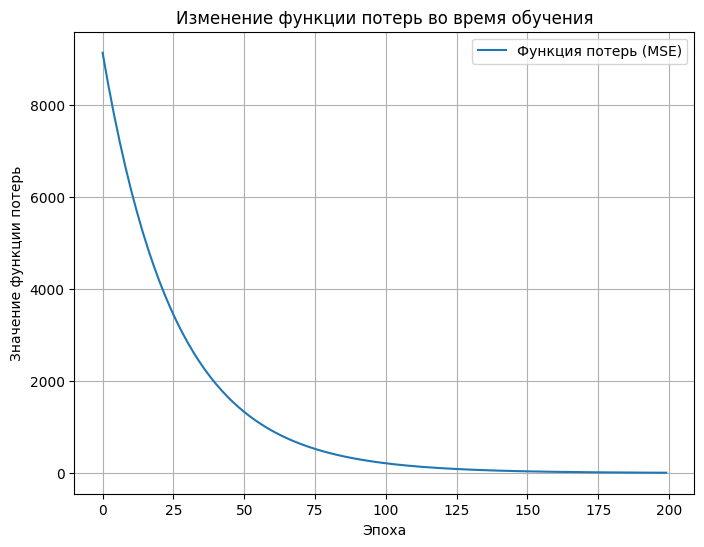

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(range(epochs), losses, label='Функция потерь (MSE)')
plt.xlabel('Эпоха')
plt.ylabel('Значение функции потерь')
plt.title('Изменение функции потерь во время обучения')
plt.legend()
plt.grid(True)
plt.show()

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Реализуйте обратное распространение ошибки для модели нейрона с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`. Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{0} \\
w_{1} \\
\vdots \\
w_{m} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$L = \frac{1}{k}\sum_{k}{(\hat{y_k}-y_k)^2}$$

$$\nabla_{\hat{\mathbf{Y}}} L=\begin{bmatrix}
\frac{\partial L}{\partial \hat{y_1}} \\
\frac{\partial L}{\partial \hat{y_2}} \\
\vdots \\
\frac{\partial L}{\partial \hat{y_k}} \\
\end{bmatrix} = \frac{2}{k}\begin{bmatrix}
\hat{y_1} - y_1 \\
\hat{y_2} - y_2 \\
\vdots \\
\hat{y_k} - y_k \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\nabla_{\hat{\mathbf{Y}}} L}$$

- [ ] Проверено на семинаре

In [ ]:
import torch as th

class NeuronBatch:
    def __init__(self, n_features: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        # Добавьте дополнительный вес для сдвига (bias)
        # задайте requires_grad у этого тензора, чтобы иметь возможность протестировать
        # автоматическое дифференцирование от torch
        self.weights = th.randn(n_features + 1, 1, dtype = th.float32, requires_grad = grad)

    def add_ones_col(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", "n_features_with_bias"]:
        """Добавляет столбец из единиц в начало матрицы inputs"""
        batch_size = inputs.shape[0]
        ones = th.ones((batch_size, 1), dtype = th.float32)
        return th.cat((ones, inputs), dim = 1) #[batch_size, n_features + 1].

    def forward(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", 1]:
        inputs_with_bias = self.add_ones_col(inputs)
        return inputs_with_bias @ self.weights

    def backward(self, inputs: TensorType["batch", "n_features"], dnext: TensorType["batch", 1]) -> None:
        inputs_with_bias = self.add_ones_col(inputs)
        self.dweights: TensorType["n_features_with_bias", 1] = inputs_with_bias.T @ dnext

In [ ]:
class MSELoss:
    def forward(self, y_pred: TensorType["batch", 1], y_true: TensorType["batch", 1]) -> Scalar:
        return th.mean((y_pred - y_true)**2)

    def backward(self, y_pred: TensorType["batch", 1], y_true: TensorType["batch", 1]) -> None:
        batch_size = y_pred.shape[0]
        self.dinput: TensorType["batch", 1] = (2/batch_size) * (y_pred - y_true)
        return self.dinput

In [ ]:
batch_size, n_features = 4, 2
X = th.tensor([[1., 40.], [2., 30.], [3., 20.], [4., 10.]], dtype=th.float32)  # [batch_size, n_features]
w_true = th.tensor([2., 1., 0.], dtype=th.float32).reshape(-1, 1)  # [n_features + 1, 1]
Y = X @ w_true[1:] + w_true[0]

In [ ]:
neuron = NeuronBatch(n_features, seed=42, grad=True)
loss_mse = MSELoss()

y_pred = neuron.forward(X)
loss = loss_mse.forward(y_pred, Y)
loss.backward()
auto_grad = neuron.weights.grad

dnext = loss_mse.backward(y_pred, Y)
neuron.backward(X, dnext)
manual_grad = neuron.dweights

loss.item(), auto_grad, manual_grad

(17.008329391479492,
 tensor([[  4.0405],
         [  2.0618],
         [181.4090]]),
 tensor([[  4.0405],
         [  2.0618],
         [181.4090]], grad_fn=<MmBackward0>))

<p class="task" id="2"></p>

2\. Настройте модель нейрона, используя метод мини-пакетного градиентного спуска.

Используйте обратное распространение ошибки, реализованное самостоятельно. Выведите на экран полученные и правильные коэффициенты модели.

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import make_regression
from torch.utils.data import DataLoader, TensorDataset
import torch as th

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)
n_samples, n_features = X.shape
n_samples, n_features

(100, 4)

In [ ]:
batch_size = 32
dataset = TensorDataset(X, y)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
neuron = NeuronBatch(n_features = n_features, seed = 42)
mse_loss = MSELoss()

In [ ]:
learning_rate = 0.01
n_epochs = 100

for epoch in range(n_epochs):
    total_loss = 0
    for batch_X, batch_y in dataloader:
        y_pred = neuron.forward(batch_X)

        loss = mse_loss.forward(y_pred, batch_y)
        total_loss += loss.item() * batch_X.shape[0]

        dnext = mse_loss.backward(y_pred, batch_y). #dL/dy_pred
        neuron.backward(batch_X, dnext) #dL/dw

        with th.no_grad():
            neuron.weights -= learning_rate * neuron.dweights
    avg_loss = total_loss / n_samples
    if (epoch + 1) % 10 == 0:
      print(f'Эпоха [{epoch + 1}/{n_epochs}], Loss: {avg_loss:.4f}')

Эпоха [10/100], Loss: 2332.5874
Эпоха [20/100], Loss: 535.8094
Эпоха [30/100], Loss: 120.7904
Эпоха [40/100], Loss: 30.5304
Эпоха [50/100], Loss: 8.5955
Эпоха [60/100], Loss: 2.1660
Эпоха [70/100], Loss: 0.5799
Эпоха [80/100], Loss: 0.1697
Эпоха [90/100], Loss: 0.0445
Эпоха [100/100], Loss: 0.0138


In [ ]:
coef, neuron.weights[0].item(), neuron.weights[1:].flatten().tolist(), loss

(array([ 5.63754967, 86.47223763, 27.34070719, 41.48195023]),
 0.5068487524986267,
 [5.635303497314453, 86.42232513427734, 27.37704849243164, 41.36823654174805],
 tensor(0.0085))

<p class="task" id="3"></p>

3\. Реализуйте обратное распространение ошибки для модели полносвязного слоя с функцией потерь MSE при условии, что на вход нейрону поступает пакет (двумерный тензор) `inputs`.  Проверьте корректность вычисления градиентов, воспользовавшись возможностями по автоматическому дифференцированию `torch`.

Обратите внимание, что вам потребуются оба градиента $ \boldsymbol{\nabla_{\mathbf{W}} L }$ и $\boldsymbol{\nabla_{\mathbf{X}} L}$ для распространения ошибки с несколькими слоями.

$$\mathbf{X} = \begin{bmatrix}
x_{10} & x_{11} & \ldots & x_{1m} \\
x_{20} & x_{21} & \ldots & x_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
x_{k0} & x_{k1} & \ldots & x_{km} \\
\end{bmatrix}
\mathbf{Y} = \begin{bmatrix}
y_{1} \\
y_{2} \\
\vdots \\
y_{k} \\
\end{bmatrix}
\mathbf{W} = \begin{bmatrix}
w_{01} & w_{02} & \ldots & w_{0n} \\
w_{11} & w_{12} & \ldots & w_{1n} \\
\vdots & \vdots & \ddots & \vdots \\
w_{m1} & w_{m2} & \ldots & w_{mn} \\
\end{bmatrix}$$

$$\hat{\mathbf{Y}} = \mathbf{X}\times \mathbf{W}$$

$$\nabla_{\hat{\mathbf{Y}}} L = \begin{bmatrix}
\frac{\partial L}{\partial \hat{y_{11}}} & \ldots & \frac{\partial L}{\partial \hat{y_{1n}}} \\
\vdots & \vdots & \vdots \\
\frac{\partial L}{\partial \hat{y_{k1}}} & \ldots & \frac{\partial L}{\partial \hat{y_{kn}}} \\
\end{bmatrix}$$

$$\boldsymbol{\nabla_{\mathbf{W}} L = \mathbf{X}^T\times \nabla_{\hat{\mathbf{Y}}} L}$$
$$\boldsymbol{\nabla_{\mathbf{X}} L = \nabla_{\hat{\mathbf{Y}}} L\times \mathbf{W}^T}$$

- [ ] Проверено на семинаре

In [ ]:
import torch as th

class Linear:
    def __init__(self, n_features: int, n_neurons: int, seed: int | None = None, grad: bool = False):
        if seed is not None:
            th.manual_seed(seed)
        # Добавьте дополнительный вес для сдвига
        # задайте requires_grad у этого тензора, чтобы иметь возможность протестировать
        # автоматическое дифференцирование от torch
        self.weights: TensorType["n_features_with_bias", "n_neurons"] = th.randn(n_features + 1, n_neurons, requires_grad=grad)
        self.dweights = None

    def add_ones_col(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", "n_features_with_bias"]:
        """Добавляет столбец из единиц в начало матрицы inputs"""
        batch_size = inputs.shape[0]
        ones = th.ones(batch_size, 1)
        return th.cat([ones, inputs], dim=1)

    def forward(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", "n_neurons"]:
        inputs_with_bias = self.add_ones_col(inputs)
        return inputs_with_bias @ self.weights

    def backward(self, inputs: TensorType["batch", "n_features"], dnext: TensorType["batch", "n_neurons"]):
        inputs_with_bias = self.add_ones_col(inputs)
        self.dweights: TensorType["n_features_with_bias", "n_neurons"] = inputs_with_bias.T @ dnext #X.T * dL/dy_pred = dL/dw
        return th.matmul(dnext, self.weights[1:].T) #dL/dy_pred * W.T = dL/dx

In [ ]:
class MSELoss:
    def forward(self, y_pred: TensorType["batch", "n_neurons"], y_true: TensorType["batch", "n_neurons"]) -> Scalar:
        return th.mean((y_pred - y_true)**2)

    def backward(self, y_pred: TensorType["batch", "n_neurons"], y_true: TensorType["batch", "n_neurons"]) -> None:
        batch_size, n_neurons = y_pred.shape
        n = batch_size * n_neurons
        self.dinput = 2 * (y_pred - y_true) / n
        return self.dinput

In [ ]:
batch_size, n_features, n_neurons = 4, 3, 2
X = th.randn(batch_size, n_features, requires_grad=True)
y_true = th.randn(batch_size, n_neurons)


linear = Linear(n_features, n_neurons, seed=42, grad=True)

y_pred = linear.forward(X)
loss = mse_loss.forward(y_pred, y_true)

loss.backward()


dL_dy = mse_loss.backward(y_pred, y_true)
dL_dx = linear.backward(X, dL_dy)

print("Аналитическая dW:", linear.dweights)
print("Autograd dW:", linear.weights.grad)

print("Аналитическая dX:", dL_dx)
print("Autograd dX:", X.grad)

Аналитическая dW: tensor([[-0.8188, -0.1127],
        [-1.4115,  0.5135],
        [-0.5955, -0.4549],
        [ 2.4383, -0.8880]], grad_fn=<MmBackward0>)
Autograd dW: tensor([[-0.8188, -0.1127],
        [-1.4115,  0.5135],
        [-0.5955, -0.4549],
        [ 2.4383, -0.8880]])
Аналитическая dX: tensor([[-0.0501,  0.0467,  0.1196],
        [-0.2192,  1.1394, -2.3390],
        [ 0.0299, -0.4132,  1.1081],
        [ 0.0213,  0.1675, -0.6250]], grad_fn=<MmBackward0>)
Autograd dX: tensor([[-0.0501,  0.0467,  0.1196],
        [-0.2192,  1.1394, -2.3390],
        [ 0.0299, -0.4132,  1.1081],
        [ 0.0213,  0.1675, -0.6250]])


<p class="task" id="4"></p>

4\. Настройте полносвязный слой, используя метод пакетного градиентного спуска. Используйте обратное распространение ошибки, реализованное самостоятельно. Выведите на экран полученные и правильные коэффициенты модели.

- [ ] Проверено на семинаре

In [ ]:
from sklearn.datasets import make_regression
import torch as th

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [ ]:
learning_rate = 0.01
n_epochs = 1000
batch_size, n_features = X.shape
n_neurons = y.shape[1]

linear = Linear(n_features, n_neurons, seed = 42, grad = True)
mse_loss = MSELoss()

for epoch in range(n_epochs):
    y_pred = linear.forward(X)
    loss = mse_loss.forward(y_pred, y)

    dl_dy = mse_loss.backward(y_pred, y)
    dl_dx = linear.backward(X, dl_dy)

    with th.no_grad():
        linear.weights -= learning_rate * linear.dweights

    if (epoch + 1) % 100 == 0:
      print(f'Эпоха [{epoch + 1}/{n_epochs}], Loss: {loss.item():.4f}')

Эпоха [100/1000], Loss: 228.6233
Эпоха [200/1000], Loss: 7.4211
Эпоха [300/1000], Loss: 0.3003
Эпоха [400/1000], Loss: 0.0135
Эпоха [500/1000], Loss: 0.0006
Эпоха [600/1000], Loss: 0.0000
Эпоха [700/1000], Loss: 0.0000
Эпоха [800/1000], Loss: 0.0000
Эпоха [900/1000], Loss: 0.0000
Эпоха [1000/1000], Loss: 0.0000


In [ ]:
coef, linear.weights[0].item(), linear.weights[1:]

(array([ 5.63754967, 86.47223763, 27.34070719, 41.48195023]),
 0.5000028610229492,
 tensor([[ 5.6376],
         [86.4720],
         [27.3408],
         [41.4818]], grad_fn=<SliceBackward0>))

<p class="task" id="5"></p>

5\. Используя решения предыдущих задач, создайте нейросеть и решите задачу регрессии. При наличии корректно реализованных методов `backward` у `Linear` и `MSE` вы можете обобщить процедуру распространения ошибки на любое количество слоев. Реализуйте и обучите модель, состояющую из двух полносвязных слоев:

1. Полносвязный слой с 10 нейронами;
2. Полносвязный слой с 1 нейроном;

Схематично процедура обратного распространения ошибки представлена на рис. ниже.

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).


- [ ] Проверено на семинаре

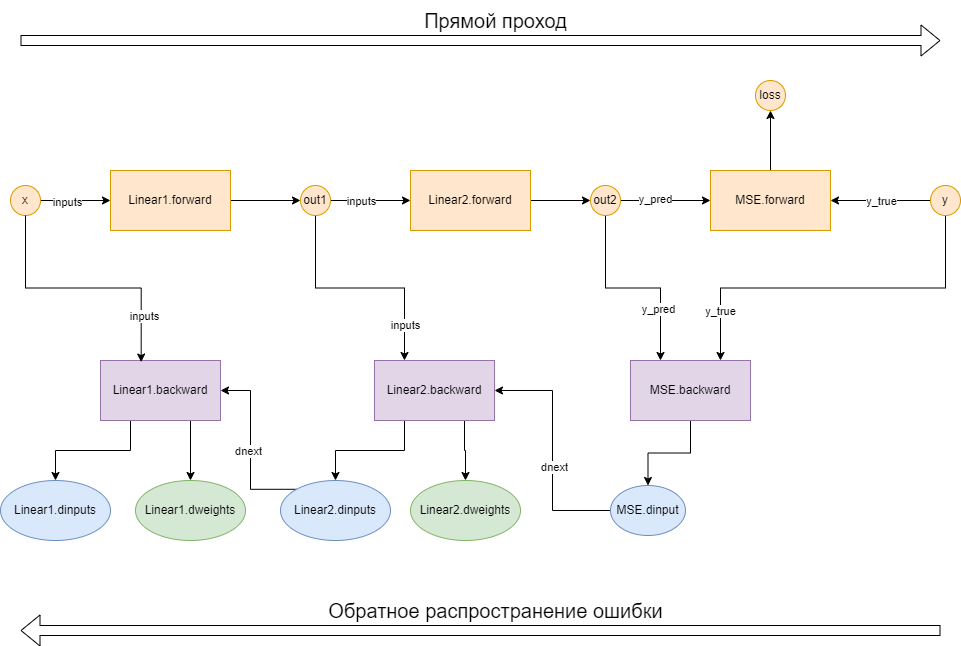

In [ ]:
import torch as th
import matplotlib.pyplot as plt

th.manual_seed(42)
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())
X.shape

torch.Size([100, 1])

In [ ]:
learning_rate = 0.001
n_epochs = 2000
batch_size, n_features = X.shape
n_neurons_1 = 10
n_neurons_2 = 1

layer1 = Linear(n_features, n_neurons_1, seed = 42, grad = True)
layer2 = Linear(n_neurons_1, n_neurons_2, seed = 42, grad = True)
mse_loss = MSELoss()

predict = []
s_epochs = [0, 500, 1000, 1500, 1999]

for epoch in range(n_epochs):
      h1= layer1.forward(X) #[100,10]
      y_pred = layer2.forward(h1) #[100,1]

      loss = mse_loss.forward(y_pred, y)

      if epoch in s_epochs:
        predict.append(y_pred.detach().clone())

      dL_dy = mse_loss.backward(y_pred, y)
      dL_dh1 = layer2.backward(h1, dL_dy)
      dL_dx = layer1.backward(X, dL_dh1)

      with th.no_grad():
        layer1.weights -= learning_rate * layer1.dweights
        layer2.weights -= learning_rate * layer2.dweights


      if (epoch + 1) % 100 == 0:
        print(f"Эпоха {epoch + 1}, Loss: {loss.item():.6f}")


Эпоха 100, Loss: 0.475290
Эпоха 200, Loss: 0.229251
Эпоха 300, Loss: 0.144611
Эпоха 400, Loss: 0.114476
Эпоха 500, Loss: 0.103666
Эпоха 600, Loss: 0.099777
Эпоха 700, Loss: 0.098377
Эпоха 800, Loss: 0.097873
Эпоха 900, Loss: 0.097691
Эпоха 1000, Loss: 0.097626
Эпоха 1100, Loss: 0.097602
Эпоха 1200, Loss: 0.097594
Эпоха 1300, Loss: 0.097591
Эпоха 1400, Loss: 0.097590
Эпоха 1500, Loss: 0.097589
Эпоха 1600, Loss: 0.097589
Эпоха 1700, Loss: 0.097589
Эпоха 1800, Loss: 0.097589
Эпоха 1900, Loss: 0.097589
Эпоха 2000, Loss: 0.097589


In [ ]:
layer1.weights.grad = None
layer2.weights.grad = None
h1 = layer1.forward(X)
y_pred = layer2.forward(h1)
loss = mse_loss.forward(y_pred, y)
loss.backward()
print("Аналитическая dW:", layer1.dweights)
print("Autograd dW:", layer1.weights.grad)

print("Аналитическая dW:", layer2.dweights)
print("Autograd dW:", layer2.weights.grad)

Аналитическая dW: tensor([[ 2.2259e-07,  1.7800e-07, -7.0548e-08,  6.5519e-07, -5.0612e-08,
         -1.7919e-06,  7.7579e-07, -1.5087e-07, -5.6862e-09, -8.5495e-07],
        [-1.0308e-05, -8.0597e-06,  3.1367e-06, -2.9474e-05,  2.3129e-06,
          8.2299e-05, -3.5495e-05,  6.9663e-06,  2.5390e-07,  3.9011e-05]],
       grad_fn=<MmBackward0>)
Autograd dW: tensor([[ 2.4098e-07,  1.8766e-07, -7.5146e-08,  7.1479e-07, -5.4075e-08,
         -1.9409e-06,  8.2515e-07, -1.6519e-07, -6.1154e-09, -9.2434e-07],
        [-1.0250e-05, -8.0150e-06,  3.1185e-06, -2.9307e-05,  2.2999e-06,
          8.1837e-05, -3.5308e-05,  6.9262e-06,  2.5262e-07,  3.8795e-05]])
Аналитическая dW: tensor([[-9.5554e-07],
        [-2.1282e-05],
        [ 1.0373e-05],
        [-1.1752e-05],
        [ 1.0883e-05],
        [-1.0453e-05],
        [ 1.7639e-05],
        [-6.4937e-06],
        [-2.0527e-05],
        [ 3.4145e-05],
        [-3.4591e-05]], grad_fn=<MmBackward0>)
Autograd dW: tensor([[-1.0580e-06],
        [-

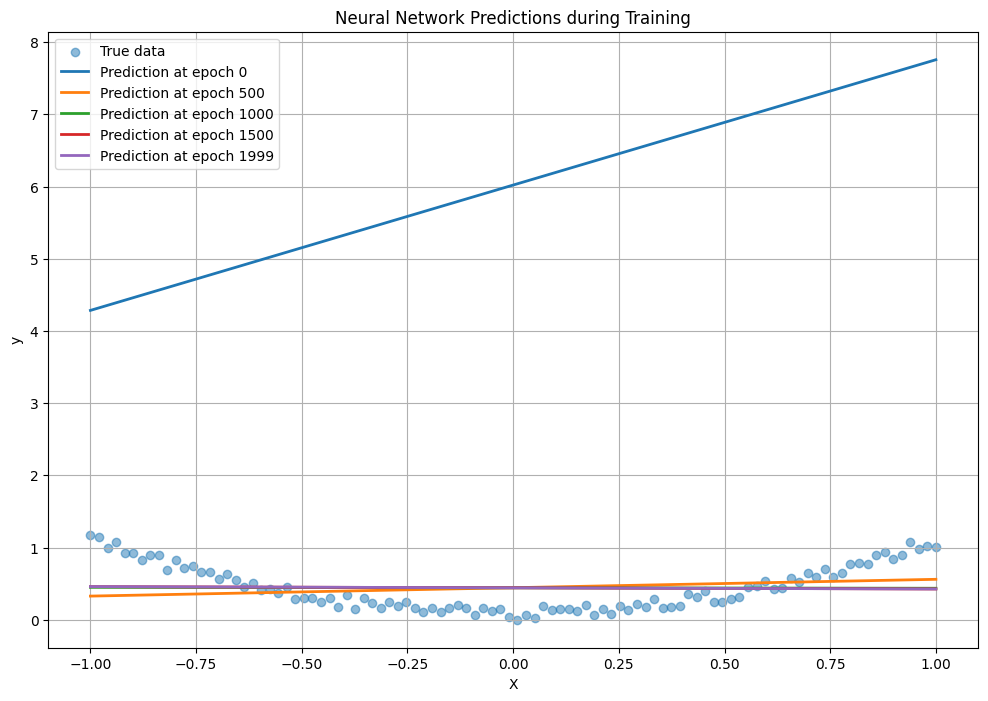

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(X.numpy(), y.numpy(), label="True data", alpha=0.5)
for i, epoch in enumerate(s_epochs):
    plt.plot(X.numpy(), predict[i].numpy(), label=f"Prediction at epoch {epoch}", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Neural Network Predictions during Training")
plt.legend()
plt.grid(True)
plt.show()

<p class="task" id="6"></p>

6\. Модель из предыдущей задачи является линейной и не способна качественно предсказать искомую зависимость. Для того, чтобы сделать модель нелинейной, в нейронных сетях используются функции активации. Для того, чтобы встроить такую функцию в процесс обратного распространения ошибки, необходимо реализовать соответствующий слой с методами `forward` и `backward`.

$$
f(x) = \max(0, x)
$$

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial f}\frac{\partial f}{\partial x} = \frac{\partial L}{\partial f}
\begin{cases}
1 & \text{если } x \ge 0 \\
0 & \text{если } x <  0
\end{cases}
$$

Здесь $L$ - это функция (слой), следующая за ReLU в потоке вычислений.

Реализуйте и обучите модель, состояющую из двух полносвязных слоев, разделенных функцией активации ReLU:
1. Полносвязный слой с 10 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).




- [ ] Проверено на семинаре

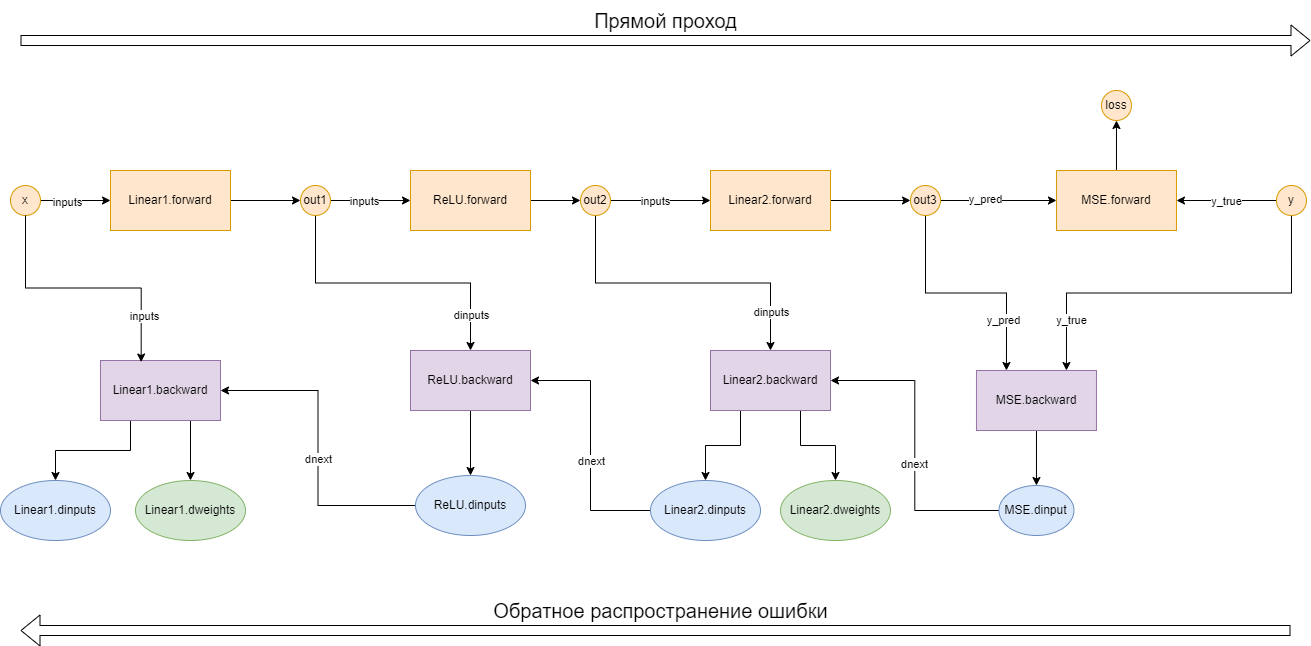

In [ ]:
class ReLU:
    def forward(self, inputs: TensorType["batch", "n_features"]) -> TensorType["batch", "n_features"]:
        self.inputs = inputs
        return th.max(th.zeros_like(inputs), inputs)

    def backward(
        self,
        inputs: TensorType["batch", "n_features"],
        dvalues: TensorType["batch", "n_features"]
    ) -> TensorType["batch", "n_features"]:
        return dvalues * (self.inputs >= 0).float()

In [ ]:
import torch as th

th.manual_seed(42)
X = th.linspace(-1, 1, 100).view(-1, 1)
y = X.pow(2) + 0.2 * th.rand(X.size())

In [ ]:
learning_rate = 0.01
n_epochs = 2000
batch_size, n_features = X.shape
n_neurons_1 = 10
n_neurons_2 = 1

layer1 = Linear(n_features, n_neurons_1, seed = 42, grad = True)
relu = ReLU()
layer2 = Linear(n_neurons_1, n_neurons_2, seed = 42, grad = True)
mse_loss = MSELoss()

predict = []
s_epochs = [0, 500, 1000, 1500, 1999]

In [ ]:
for epoch in range(n_epochs):
    h1 = layer1.forward(X)
    h2 = relu.forward(h1)
    y_pred = layer2.forward(h2)

    loss = mse_loss.forward(y_pred, y)

    if epoch in s_epochs:
      predict.append(y_pred.detach().clone())

    dL_dy = mse_loss.backward(y_pred, y)
    dL_dh2 = layer2.backward(h2, dL_dy)
    dL_dh1 = relu.backward(h1, dL_dh2)
    dL_dx = layer1.backward(X, dL_dh1)

    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss.item():.6f}, , Grad Layer 1: {th.norm(layer1.dweights).item():.6f}, Grad Layer 2: {th.norm(layer2.dweights).item():.6f}")

    with th.no_grad():
      layer1.weights -= learning_rate*layer1.dweights
      layer2.weights -= learning_rate*layer2.dweights
      layer1.dweights = th.zeros_like(layer1.dweights)
      layer2.dweights = th.zeros_like(layer2.dweights)

Epoch 1, Loss: 13.451341, , Grad Layer 1: 16.800034, Grad Layer 2: 24.340359
Epoch 100, Loss: 0.100131, , Grad Layer 1: 0.101957, Grad Layer 2: 0.037359
Epoch 200, Loss: 0.096451, , Grad Layer 1: 0.016592, Grad Layer 2: 0.044478
Epoch 300, Loss: 0.094163, , Grad Layer 1: 0.016761, Grad Layer 2: 0.045585
Epoch 400, Loss: 0.091695, , Grad Layer 1: 0.020912, Grad Layer 2: 0.046592
Epoch 500, Loss: 0.088912, , Grad Layer 1: 0.025798, Grad Layer 2: 0.048152
Epoch 600, Loss: 0.085728, , Grad Layer 1: 0.029677, Grad Layer 2: 0.050029
Epoch 700, Loss: 0.082110, , Grad Layer 1: 0.034046, Grad Layer 2: 0.051984
Epoch 800, Loss: 0.078056, , Grad Layer 1: 0.037044, Grad Layer 2: 0.053818
Epoch 900, Loss: 0.073605, , Grad Layer 1: 0.038588, Grad Layer 2: 0.055358
Epoch 1000, Loss: 0.068894, , Grad Layer 1: 0.040847, Grad Layer 2: 0.056344
Epoch 1100, Loss: 0.064008, , Grad Layer 1: 0.041042, Grad Layer 2: 0.056762
Epoch 1200, Loss: 0.059035, , Grad Layer 1: 0.042348, Grad Layer 2: 0.056664
Epoch 13

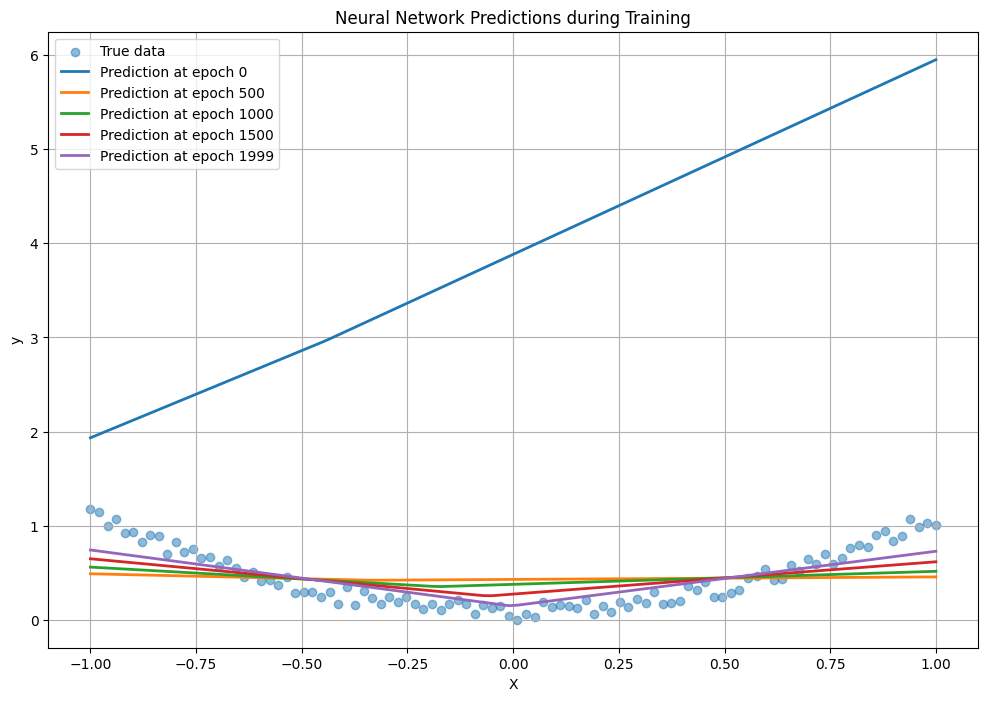

In [ ]:
plt.figure(figsize=(12, 8))
plt.scatter(X.numpy(), y.numpy(), label="True data", alpha=0.5)
for i, epoch in enumerate(s_epochs):
    plt.plot(X.numpy(), predict[i].numpy(), label=f"Prediction at epoch {epoch}", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Neural Network Predictions during Training")
plt.legend()
plt.grid(True)
plt.show()